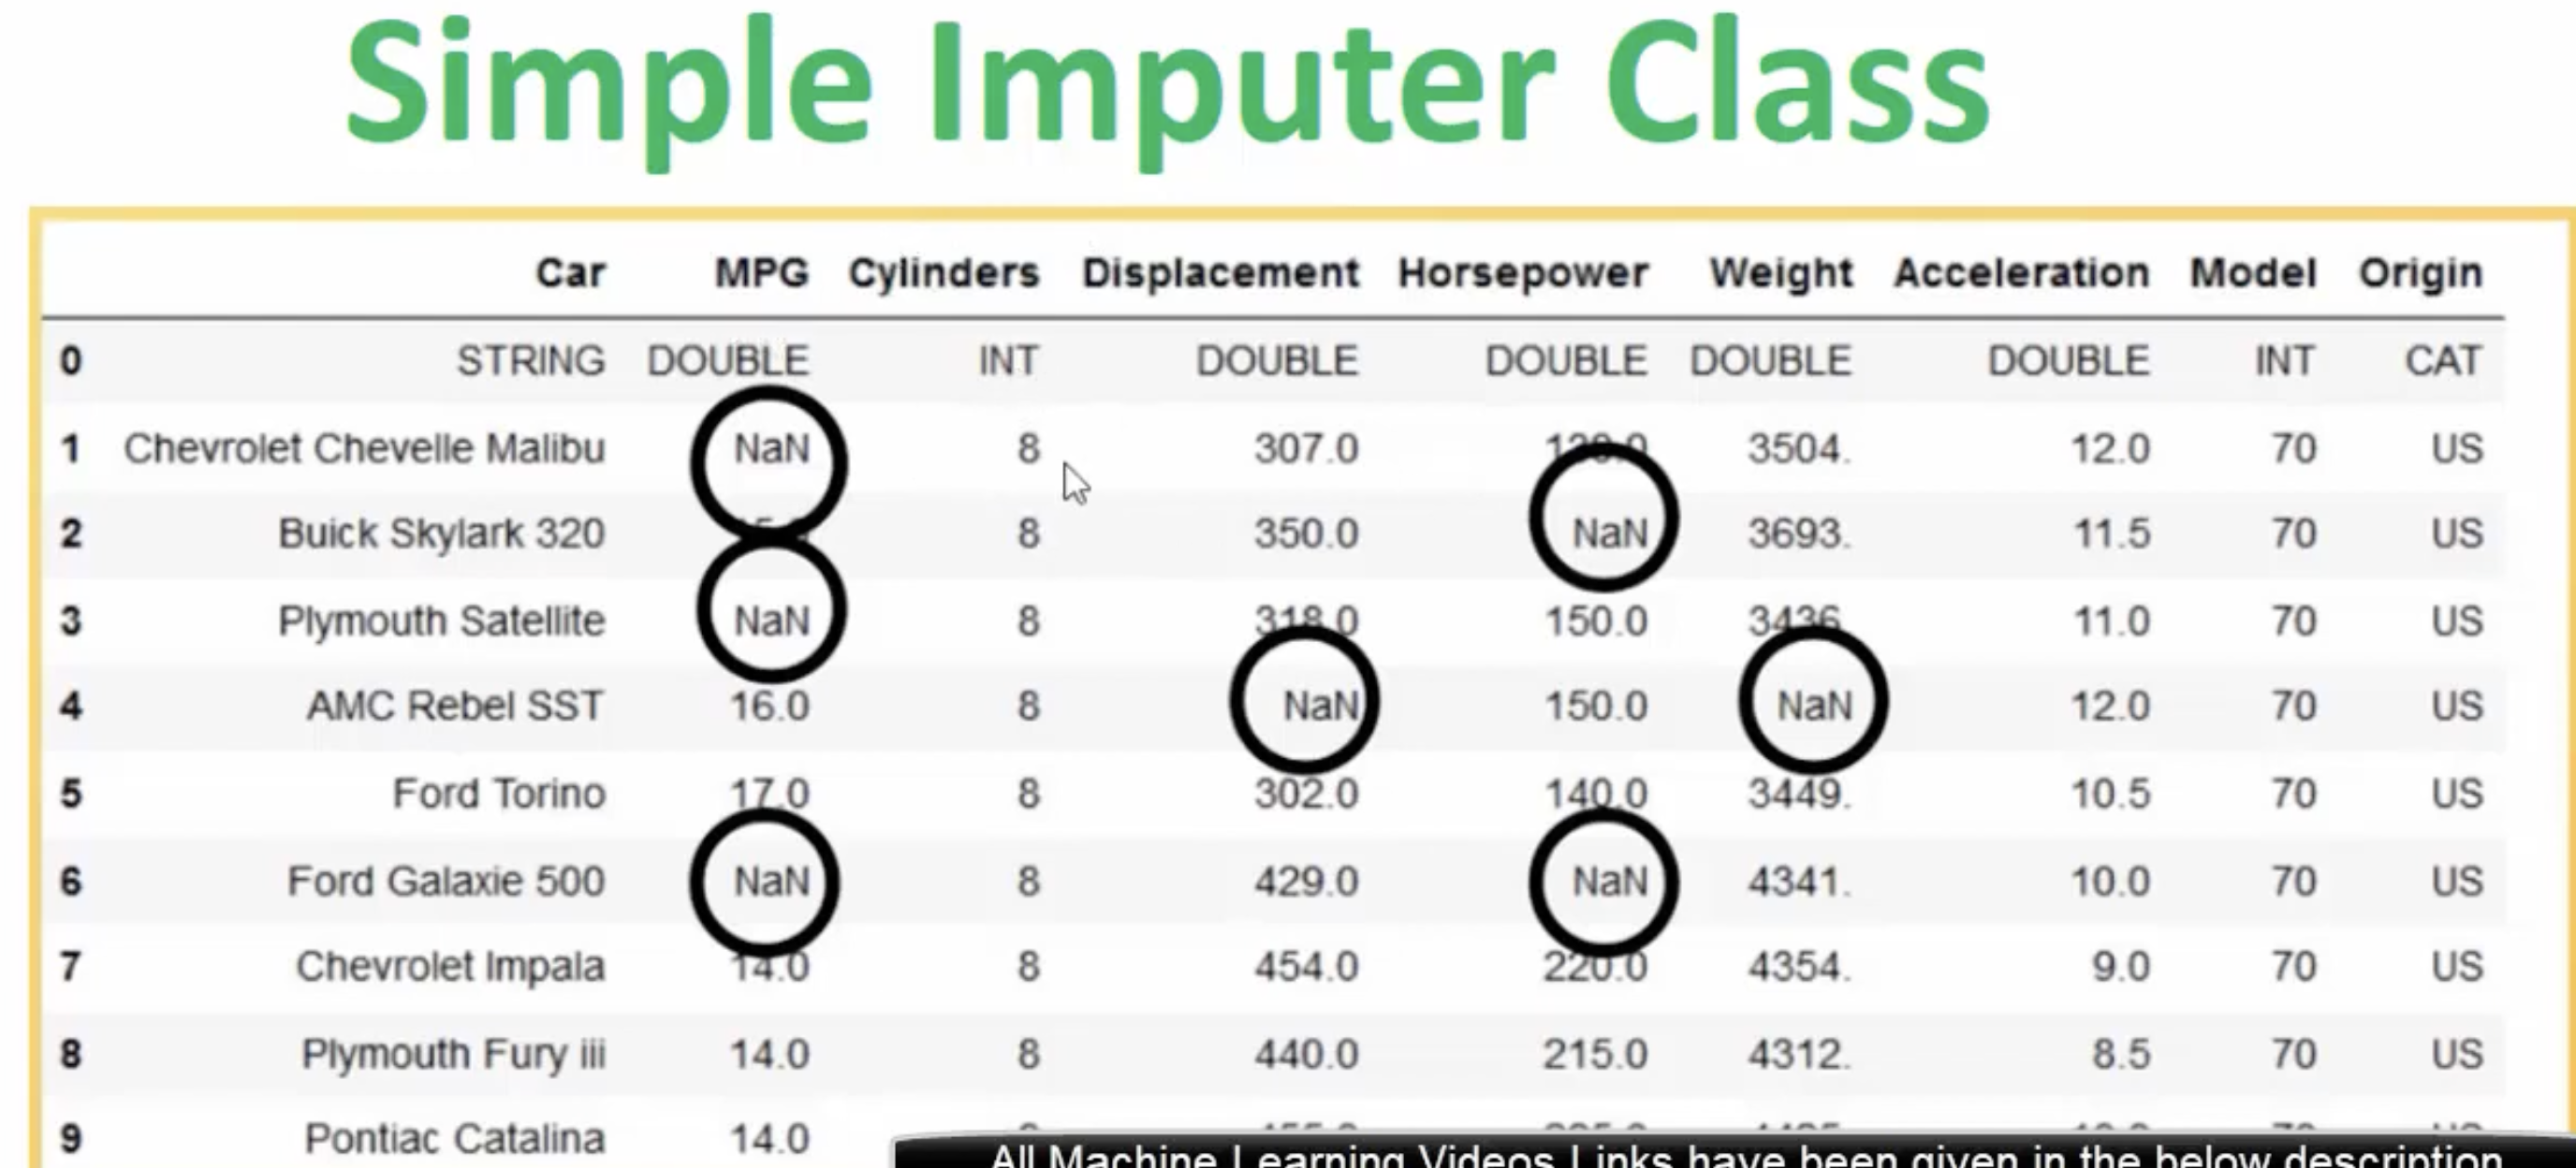

In [22]:
import pandas as pd
import sklearn 
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/8_df.csv')
df

,Unnamed: 0,A,B,C,D
0,0,1.0,NaN,1.0,1.0
1,1,2.0,2.0,2.0,2.0
2,2,3.0,3.0,NaN,3.0
3,3,NaN,2.0,4.0,4.0
4,4,5.0,5.0,5.0,NaN
5,5,6.0,6.0,NaN,6.0
6,6,3.0,3.0,3.0,7.0
7,7,NaN,3.0,4.0,8.0
8,8,8.0,NaN,4.0,9.0
9,9,9.0,9.0,9.0,10.0


In [23]:
df.isnull().sum()

Unnamed: 0    0
A             2
B             2
C             2
D             1
dtype: int64

## Simple Imputor

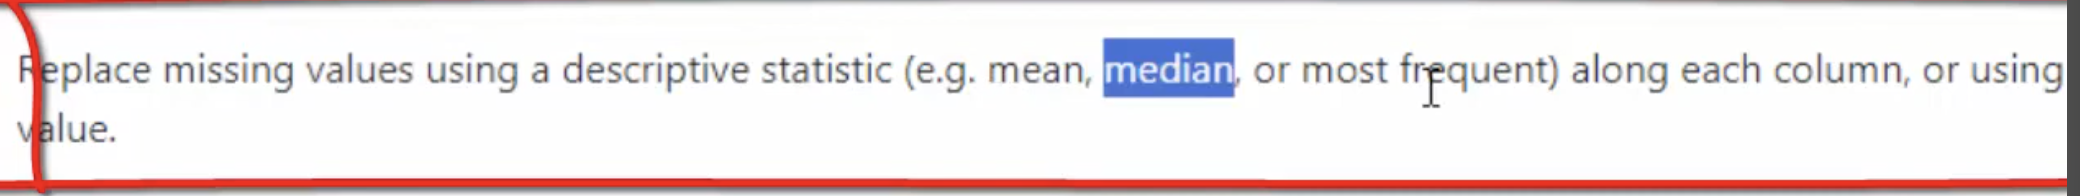

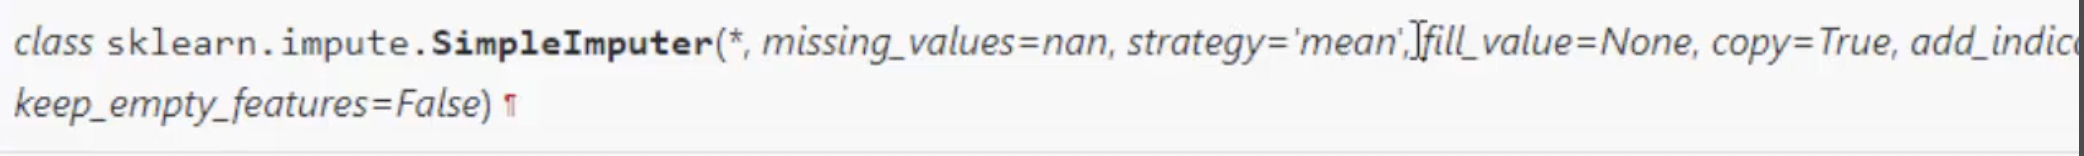

In [24]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='mean')

In [25]:
df['A']=si.fit_transform(df[['A']])
df

,Unnamed: 0,A,B,C,D
0,0,1.000,NaN,1.0,1.0
1,1,2.000,2.0,2.0,2.0
2,2,3.000,3.0,NaN,3.0
3,3,4.625,2.0,4.0,4.0
4,4,5.000,5.0,5.0,NaN
5,5,6.000,6.0,NaN,6.0
6,6,3.000,3.0,3.0,7.0
7,7,4.625,3.0,4.0,8.0
8,8,8.000,NaN,4.0,9.0
9,9,9.000,9.0,9.0,10.0


In [26]:
df['B']=si.fit_transform(df[['B']])
df

,Unnamed: 0,A,B,C,D
0,0,1.000,4.125,1.0,1.0
1,1,2.000,2.000,2.0,2.0
2,2,3.000,3.000,NaN,3.0
3,3,4.625,2.000,4.0,4.0
4,4,5.000,5.000,5.0,NaN
5,5,6.000,6.000,NaN,6.0
6,6,3.000,3.000,3.0,7.0
7,7,4.625,3.000,4.0,8.0
8,8,8.000,4.125,4.0,9.0
9,9,9.000,9.000,9.0,10.0


In [27]:
si2=si=SimpleImputer(strategy='median')
df['C']=si2.fit_transform(df[['C']])
df

,Unnamed: 0,A,B,C,D
0,0,1.000,4.125,1.0,1.0
1,1,2.000,2.000,2.0,2.0
2,2,3.000,3.000,4.0,3.0
3,3,4.625,2.000,4.0,4.0
4,4,5.000,5.000,5.0,NaN
5,5,6.000,6.000,4.0,6.0
6,6,3.000,3.000,3.0,7.0
7,7,4.625,3.000,4.0,8.0
8,8,8.000,4.125,4.0,9.0
9,9,9.000,9.000,9.0,10.0


In [28]:
si3=si=SimpleImputer(strategy='mode')
df['D']=si2.fit_transform(df[['D']])
df


,Unnamed: 0,A,B,C,D
0,0,1.000,4.125,1.0,1.0
1,1,2.000,2.000,2.0,2.0
2,2,3.000,3.000,4.0,3.0
3,3,4.625,2.000,4.0,4.0
4,4,5.000,5.000,5.0,6.0
5,5,6.000,6.000,4.0,6.0
6,6,3.000,3.000,3.0,7.0
7,7,4.625,3.000,4.0,8.0
8,8,8.000,4.125,4.0,9.0
9,9,9.000,9.000,9.0,10.0


In [29]:
pdf=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/9 covid_toy.csv')
pdf

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No
...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No
96,51,Female,101.0,Strong,Kolkata,Yes
97,20,Female,101.0,Mild,Bangalore,No
98,5,Female,98.0,Strong,Mumbai,No


In [30]:
from sklearn.model_selection import train_test_split
y=pdf['has_covid']
X=pdf.drop(columns='has_covid')

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [31]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((80, 5), (20, 5), (80,), (20,))

In [32]:
X['fever'].isnull().sum()

np.int64(10)

## Without column transformer


In [33]:
from sklearn.impute import SimpleImputer
si=SimpleImputer()

X_train_fever=si.fit_transform(X_train[['fever']])
X_test_fever=si.fit_transform(X_test[['fever']])


In [37]:
## encoding categorical values
from sklearn.preprocessing import OrdinalEncoder
ordinal=OrdinalEncoder(categories=[['Mild','Strong']])

## i want small no to mild and big no to strong

X_train_cough=ordinal.fit_transform(X_train[['cough']])
X_test_cough=ordinal.fit_transform(X_test[['cough']])
X_train_cough

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],

In [39]:
X_train_cough.shape

(80, 1)

In [42]:
## gender and city -> one hot encoding

from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop='first',sparse_output=False)
X_train

,age,gender,fever,cough,city
55,81,Female,101.0,Mild,Mumbai
88,5,Female,100.0,Mild,Kolkata
26,19,Female,100.0,Mild,Kolkata
42,27,Male,100.0,Mild,Delhi
69,73,Female,103.0,Mild,Delhi
...,...,...,...,...,...
60,24,Female,102.0,Strong,Bangalore
71,75,Female,104.0,Strong,Delhi
14,51,Male,104.0,Mild,Bangalore
92,82,Female,102.0,Strong,Kolkata


In [ ]:
X_train_gender_city=ohe.fit_transform(X_train[['gender','city']])
X_test_gender_city=ohe.fit_transform(X_test[['gender','city']])
X_train_gender_city.shape
## 1 col for gender and 2 for cities as gender has two columns but we dropped first one 

(80, 4)

In [50]:
## Extracting age

X_train_age=X_train.drop(columns=['gender','fever','cough','city']).values
X_test_age=X_test.drop(columns=['gender','fever','cough','city']).values

print(X_train_age.shape)

## concatenate everything by sending tuple of tuple

X_train_transformed=np.concatenate((X_train_age,X_train_fever,X_train_gender_city,X_train_cough),axis=1)
X_test_transformed=np.concatenate((X_test_age,X_test_fever,X_test_gender_city,X_test_cough),axis=1)
X_train_transformed

(80, 1)


array([[ 81., 101.,   0.,   0.,   0.,   1.,   0.],
       [  5., 100.,   0.,   0.,   1.,   0.,   0.],
       [ 19., 100.,   0.,   0.,   1.,   0.,   0.],
       [ 27., 100.,   1.,   1.,   0.,   0.,   0.],
       [ 73., 103.,   0.,   1.,   0.,   0.,   0.],
       [ 70., 103.,   1.,   0.,   1.,   0.,   1.],
       [ 49., 102.,   0.,   1.,   0.,   0.,   0.],
       [ 51., 101.,   0.,   0.,   1.,   0.,   1.],
       [ 64., 101.,   0.,   1.,   0.,   0.,   0.],
       [ 83., 101.,   0.,   0.,   1.,   0.,   0.],
       [ 65.,  98.,   0.,   0.,   0.,   1.,   0.],
       [ 18., 104.,   0.,   0.,   0.,   0.,   0.],
       [ 16., 103.,   0.,   0.,   0.,   0.,   0.],
       [ 16., 104.,   1.,   0.,   1.,   0.,   0.],
       [ 27., 100.,   1.,   0.,   1.,   0.,   0.],
       [ 84., 101.,   0.,   0.,   0.,   0.,   0.],
       [ 51., 104.,   1.,   0.,   1.,   0.,   0.],
       [ 69., 102.,   0.,   0.,   0.,   0.,   0.],
       [ 82., 102.,   0.,   0.,   0.,   0.,   1.],
       [ 69., 103.,   0.,   0.,

## With column transformers

In [53]:
X_train

,age,gender,fever,cough,city
55,81,Female,101.0,Mild,Mumbai
88,5,Female,100.0,Mild,Kolkata
26,19,Female,100.0,Mild,Kolkata
42,27,Male,100.0,Mild,Delhi
69,73,Female,103.0,Mild,Delhi
...,...,...,...,...,...
60,24,Female,102.0,Strong,Bangalore
71,75,Female,104.0,Strong,Delhi
14,51,Male,104.0,Mild,Bangalore
92,82,Female,102.0,Strong,Kolkata


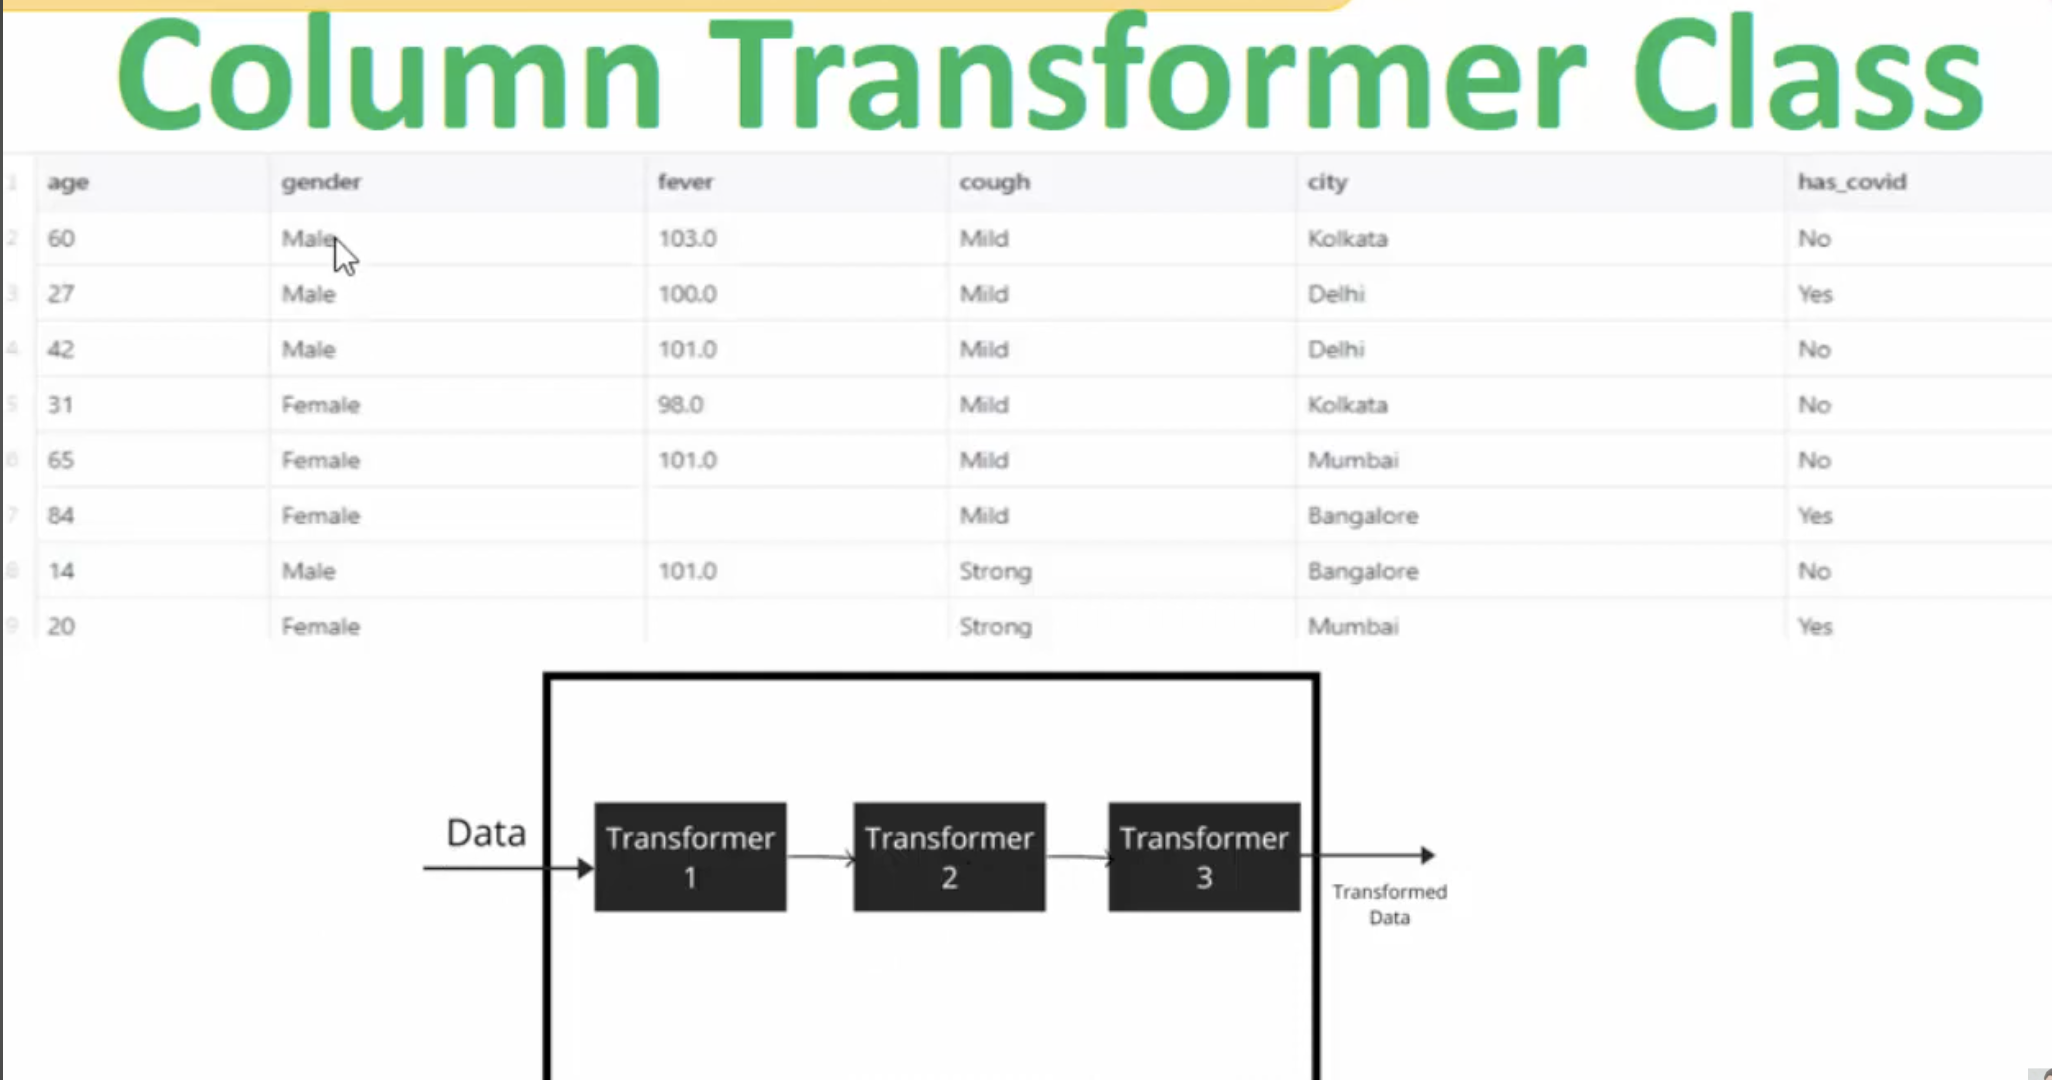

in col transformer,we can do all the preprocessing steps like OneHotencoder,Ordinal encoders,label encoder in one line of code




In [54]:
from sklearn.compose import ColumnTransformer

In [ ]:
## in transformer we write all the preprocessing steps
## transformers= [(name_transformer,typeofpreprocessing,cols to apply)]
## there is one more parameter remainder --> what to do with remaining columns and we set it to passthrough means do nothing


In [56]:
tf=ColumnTransformer(

transformers=[
#transformer_name, type of preprocessing, cols to apply
('tf1'      ,SimpleImputer(),  ['fever']),
('tf2',OrdinalEncoder(categories=[['Mild','Strong']]),['cough']),
('tf3',OneHotEncoder(drop='first',sparse_output=False),['gender','city'])
],
remainder="passthrough" ## remaining cols ke upper khuch opn mat karna
)

In [57]:
tf

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tf1', ...), ('tf2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

In [58]:
X_train_tf=tf.fit_transform(X_train)
X_test_tf=tf.fit_transform(X_test)

In [60]:
X_train_tf

array([[101.,   0.,   0.,   0.,   0.,   1.,  81.],
       [100.,   0.,   0.,   0.,   1.,   0.,   5.],
       [100.,   0.,   0.,   0.,   1.,   0.,  19.],
       [100.,   0.,   1.,   1.,   0.,   0.,  27.],
       [103.,   0.,   0.,   1.,   0.,   0.,  73.],
       [103.,   1.,   1.,   0.,   1.,   0.,  70.],
       [102.,   0.,   0.,   1.,   0.,   0.,  49.],
       [101.,   1.,   0.,   0.,   1.,   0.,  51.],
       [101.,   0.,   0.,   1.,   0.,   0.,  64.],
       [101.,   0.,   0.,   0.,   1.,   0.,  83.],
       [ 98.,   0.,   0.,   0.,   0.,   1.,  65.],
       [104.,   0.,   0.,   0.,   0.,   0.,  18.],
       [103.,   0.,   0.,   0.,   0.,   0.,  16.],
       [104.,   0.,   1.,   0.,   1.,   0.,  16.],
       [100.,   0.,   1.,   0.,   1.,   0.,  27.],
       [101.,   0.,   0.,   0.,   0.,   0.,  84.],
       [104.,   0.,   1.,   0.,   1.,   0.,  51.],
       [102.,   0.,   0.,   0.,   0.,   0.,  69.],
       [102.,   1.,   0.,   0.,   0.,   0.,  82.],
       [103.,   0.,   0.,   0.,